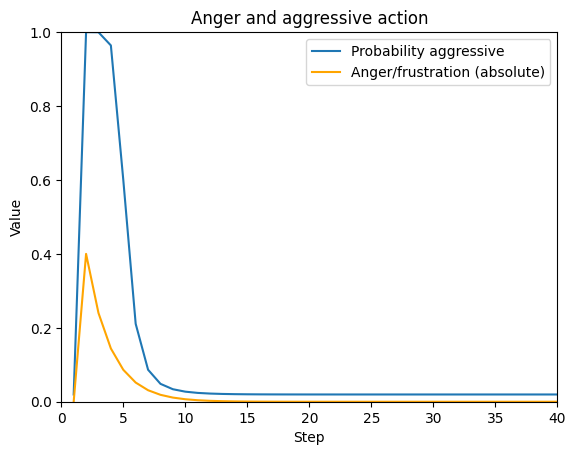

,,V,M_A,theta_N_w0,theta_N_w1,theta_N,theta_F_w0,theta_F_w1,theta_F,theta_A_w0,theta_A_w1,theta_A,p_N,p_F,p_A,a,r,rpe,lambda_A,C
Step,AgentID,,,,,,,,,,,,,,,,,,,
1,1,0,0.000,3.892,0,3.892,0,0,0,0,-50,0.000,0.961,0.020,0.020,NEUTRAL,-1,-1,0.600,1
2,1,0,-0.400,3.892,0,3.892,0,0,0,0,-50,20.000,0.000,0.000,1.000,AGGRESSIVE,0,0,0.600,1
3,1,0,-0.240,3.892,0,3.892,0,0,0,0,-50,12.000,0.000,0.000,1.000,AGGRESSIVE,0,0,0.600,1
4,1,0,-0.144,3.892,0,3.892,0,0,0,0,-50,7.200,0.035,0.001,0.964,AGGRESSIVE,0,0,0.600,1
5,1,0,-0.086,3.892,0,3.892,0,0,0,0,-50,4.320,0.391,0.008,0.601,NEUTRAL,0,0,0.600,1
6,1,0,-0.052,3.892,0,3.892,0,0,0,0,-50,2.592,0.773,0.016,0.211,NEUTRAL,0,0,0.600,1
7,1,0,-0.031,3.892,0,3.892,0,0,0,0,-50,1.555,0.895,0.018,0.087,NEUTRAL,0,0,0.600,1
8,1,0,-0.019,3.892,0,3.892,0,0,0,0,-50,0.933,0.933,0.019,0.048,NEUTRAL,0,0,0.600,1
9,1,0,-0.011,3.892,0,3.892,0,0,0,0,-50,0.560,0.947,0.019,0.034,NEUTRAL,0,0,0.600,1


In [11]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    "V": 0,
    "M_A": 0,
    # TODO: M_A at t=1 is actually not defined. but setting 0 is justified?

    # prior tendencies for neutral behavior
    "theta_N_w0": 3.892,  # should yield around 95% neutral in the beginning
    "theta_N_w1": 0,

    # prior tendencies for friendly behavior
    "theta_F_w0": 0,
    "theta_F_w1": 0,

    # prior tendencies for aggressive behavior
    "theta_A_w0": 0,
    "theta_A_w1": -50,

    # Some variables will be calculated in the model
    # or received from the environment
    "p_N": None,
    "p_A": None,
    "p_F": None,
    "r": None,
    "rpe": None,
}

init_variables["theta_N"] = init_variables["theta_N_w0"] + init_variables[
    "theta_N_w1"
]

init_variables["theta_F"] = init_variables["theta_F_w0"] + init_variables[
    "theta_F_w1"
]

init_variables["theta_A"] = init_variables["theta_A_w0"] + init_variables[
    "theta_F_w1"
]

init_parameters = {
    # parameter for the exponential moving average of anger
    "lambda_A": 0.60,

    # controllability
    "C": 1
}

starter_model = model.IrritabilityModel(init_variables=init_variables,
                                        init_parameters=init_parameters,
                                        seed=12345)

# Run a simulation for a single agent
n_ticks = 100
for _ in range(n_ticks):
    starter_model.step()

# Extract data and plot
data = starter_model.datacollector.get_agent_vars_dataframe()

g = sns.lineplot(data=data,
                 y="p_A",
                 x="Step",
                 label="Probability aggressive")

g = sns.lineplot(data=data,
                 y=data["M_A"].abs(),
                 x="Step",
                 color="Orange",
                 label="Anger/frustration (absolute)")

g.set(title="Anger and aggressive action",
      ylabel="Value");

plt.xlim(0, 40)
plt.ylim(0, 1)
plt.show()
display(data)
